# Neuroinformatics Project
**Name: Rezvan Afshoon**

**Marticulation Number: 1017747**



In this project, we analyze neural spike train data collected during experiments with familiar and unfamiliar stimuli.

Our goal is to:
- Transform the raw spike data into meaningful features,
- Train machine learning classifiers,
- Predict whether a given stimulus was familiar or unfamiliar based on neural activity,
- Compare different feature extraction and modeling strategies.

We begin by uploading and preparing the dataset for analysis.

In [2]:
from google.colab import files
uploaded = files.upload()


Saving data.zip to data.zip


In [3]:
import zipfile
import os

with zipfile.ZipFile('data.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

# List extracted files
os.listdir('data')

['y.npy', 'x.npy']

# Importing Libraries

We start by importing the essential Python libraries used throughout this project:

- **numpy** for efficient numerical operations and array manipulation.
- **matplotlib.pyplot** for plotting and visualizing the spike data and results.
- **scipy.stats.entropy** for calculating Kullback-Leibler (KL) Divergence between feature distributions.
- **scikit-learn.model_selection.train_test_split** for splitting the dataset into training and testing subsets.
- **scikit-learn.linear_model.LogisticRegression** for training a logistic regression classifier.
- **scikit-learn.metrics.accuracy_score** for evaluating model performance using accuracy.
- **scikit-learn.ensemble.RandomForestClassifier** for training an alternative classification model based on Random Forests.

These libraries provide the necessary tools for data processing, feature extraction, model building, performance evaluation, and visualizations.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier

## Loading Data

We load the dataset from pre-saved `.npy` files:

- **X** contains the raw neural spike train data, with dimensions corresponding to trials, neurons, and time steps.
- **y** contains the class labels for each trial, indicating whether the stimulus presented was familiar (`1`) or unfamiliar (`0`).

The data is loaded using `numpy.load()`, which efficiently reads arrays saved in NumPy's native format.

This prepares the input features and corresponding labels for the subsequent feature extraction and classification tasks.


In [5]:
X = np.load('data/x.npy')
y = np.load('data/y.npy')

In [6]:
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (800, 1000, 501)
y shape: (800,)


# Raster Plot

To better understand the raw spike train data, we plot a raster plot for a single trial.

In a raster plot:
- Each row represents a different neuron.
- Each vertical line represents a spike (firing event) at a specific time step.


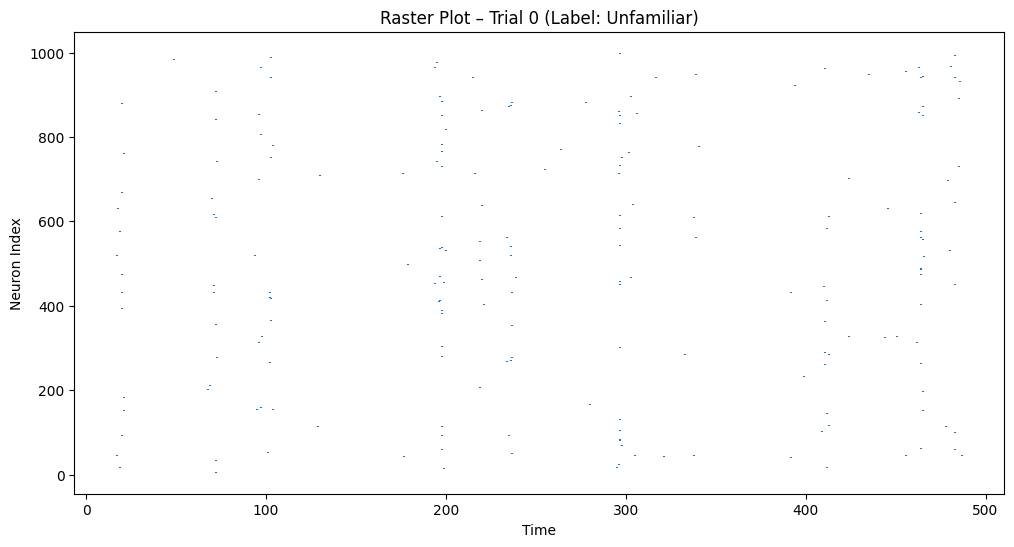

In [ ]:
# Pick any trial index (e.g., 0)
trial_idx = 0
trial_spikes = X[trial_idx]  # shape: (neurons, timesteps)

plt.figure(figsize=(12, 6))
for neuron_idx in range(trial_spikes.shape[0]):
    spike_times = np.where(trial_spikes[neuron_idx] > 0)[0]
    plt.vlines(spike_times, neuron_idx + 0.5, neuron_idx + 1.5)

plt.title(f"Raster Plot – Trial {trial_idx} (Label: {'Familiar' if y[trial_idx] == 1 else 'Unfamiliar'})")
plt.xlabel("Time")
plt.ylabel("Neuron Index")
plt.show()

# the distribution of the data
To further explore the spike train data, we calculated the total number of spikes for each trial by summing across all neurons and time steps.

We then plotted the distribution of these total spike counts across all trials.

This visualization helps us understand:
- The overall level of neural activity during different trials.
- Whether certain trials (familiar vs unfamiliar) tend to have higher or lower total firing activity.

The distribution also gives insight into the variability and typical range of neural responses in the dataset.

In [ ]:
# Total number of spikes per trial (sum over neurons and time)
spike_counts = X.sum(axis=(1, 2))  # Shape: (800,)

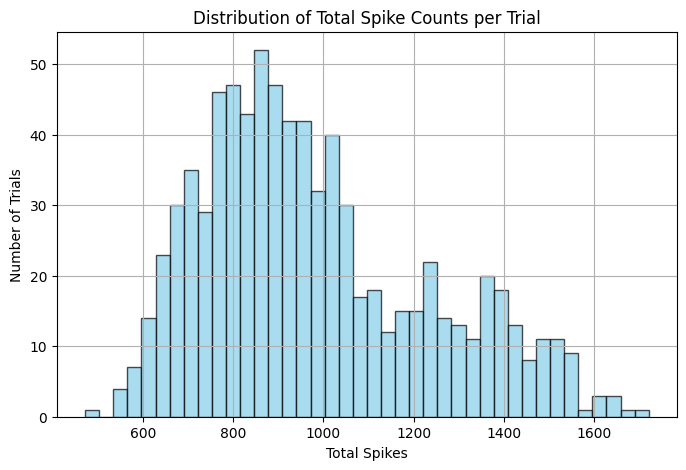

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(spike_counts, bins=40, color='skyblue', edgecolor='black', alpha=0.7)
plt.title("Distribution of Total Spike Counts per Trial")
plt.xlabel("Total Spikes")
plt.ylabel("Number of Trials")
plt.grid(True)
plt.show()

# Transform raw spikes into data suitable for classification

To prepare the raw neural spike train data for classification, we applied two neural coding strategies:

- **Rate Coding:** We computed the average firing rate for each neuron over time during each trial. This captures how active each neuron was in response to the stimulus.
- **Population Total Spikes:** We calculated the total number of spikes across all neurons and timesteps for each trial, summarizing the overall brain activation level.



##1. Rate Coding (Average spike rate per neuron)
 We want to see how active each neuron is. The higher the firing rate, the stronger the neuron's response to the stimulus. We count how many spikes a neuron fires, and the divide it by the total time. Then, we have **one feature vector** per trial.


In [ ]:
firing_rate_features = X.mean(axis=2)
print(firing_rate_features.shape)

(800, 1000)


## 2. Total spike count
 Here we measure how active the whole brain network is together. Instead of looking at each neuron individually, here we sum up all the spikes fired by all neurons across all time steps in one trial. This gives us **one number** per trial.



In [ ]:
features_total_spikes = X.sum(axis=(1, 2)).reshape(-1, 1)

# Exploratory Analysis: Distribution Comparison

In this step, we plot the distributions of the extracted feature (average firing rates) for familiar and unfamiliar stimuli.

Out of the model comparison metrics we studied during the course, we chose to use **Kullback-Leibler (KL) Divergence** here because it is specifically designed for comparing two probability distributions. KL Divergence measures how much one distribution diverges from another, making it ideal for analyzing whether the two classes (familiar vs unfamiliar) are separable based on the features.

Other metrics we learned, such as **Bias-Variance Decomposition**, **Mean Squared Error (MSE)**, **Deviance**, and **AIC**, require a trained model, as they evaluate model prediction errors or model complexity. Therefore, we will apply those metrics later, after training our first model.

At this stage, since no model is fitted yet, KL Divergence is the most appropriate choice for exploratory feature comparison.


First we seperate the data based on the class (familiar stimuli and unfamiliar stimuli)

In [ ]:

familiar_rates = firing_rate_features[y == 1].flatten()
unfamiliar_rates = firing_rate_features[y == 0].flatten()

Then we plot the distribution:

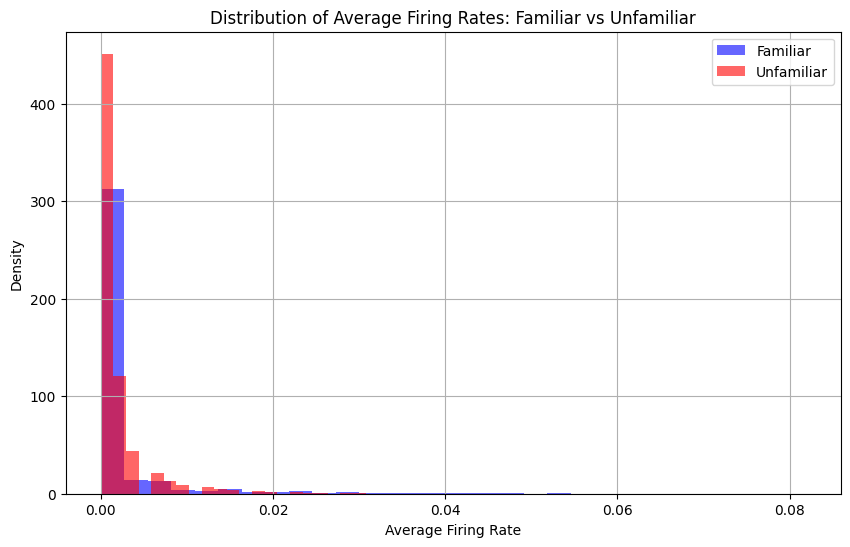

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(familiar_rates, bins=30, density=True, alpha=0.6, label='Familiar', color='blue')
plt.hist(unfamiliar_rates, bins=30, density=True, alpha=0.6, label='Unfamiliar', color='red')
plt.title("Distribution of Average Firing Rates: Familiar vs Unfamiliar")
plt.xlabel("Average Firing Rate")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()


As we can see from the plot, there is a clear difference between the distributions of average firing rates for familiar and unfamiliar stimuli.

This visible separation suggests that average firing rate is a meaningful feature for distinguishing between the two classes, and we can expect a classifier to perform well using this feature.


Now we calculate the KL Divergence.

In [ ]:
# Create histograms (probability distributions)
familiar_hist, bin_edges = np.histogram(familiar_rates, bins=50, density=True)
unfamiliar_hist, _ = np.histogram(unfamiliar_rates, bins=50, density=True)

# Avoid division by zero
epsilon = 1e-10
familiar_hist += epsilon
unfamiliar_hist += epsilon

# Calculate KL Divergence (Familiar || Unfamiliar)
kl_div = entropy(familiar_hist, unfamiliar_hist)

print(f"KL Divergence (Familiar || Unfamiliar): {kl_div:.4f}")


KL Divergence (Familiar || Unfamiliar): 4.5363


The calculated KL Divergence between the familiar and unfamiliar distributions is 4.53.

This high value indicates a strong divergence between the two distributions, meaning that the feature we extracted (average firing rate) separates the two classes very well.

**KL Divergence Value	Interpretation:**

0.0 to 0.1:	Almost no difference

0.1 to 0.5:	Small/moderate difference

0.5 to 1.5:	Noticeable/moderate difference

larger than 1.5:	Large difference


# Logistic Regression

We chose to use Logistic Regression as the classification model because it is a simple, interpretable, and effective method for binary classification tasks.

Since our goal is to distinguish between two classes (familiar vs unfamiliar stimuli) based on average firing rates, Logistic Regression provides a good baseline with easily interpretable results.



First, we prepare our data to train the model:

In [ ]:
X_features = firing_rate_features
y_labels = y


Then we split the data into train and test set.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)


We train logistic regression and make predictions



In [ ]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)


y_pred = logreg.predict(X_test)


# Model Evaluation

First we check whether the classes are balanced or not. Then we choose our evaluation metric accordingly.

In [ ]:
unique_classes, class_counts = np.unique(y, return_counts=True)

for cls, count in zip(unique_classes, class_counts):
    print(f"Class {int(cls)}: {count} samples")

Class 0: 400 samples
Class 1: 400 samples


Since the classes in our dataset are approximately balanced, we used **Accuracy** as the primary metric for evaluating the model performance.

Accuracy measures the proportion of correctly classified samples over the total number of samples. In balanced datasets, Accuracy is a reliable and intuitive metric to assess the overall effectiveness of the classifier.

The calculated accuracy score provides a straightforward evaluation of how well the model distinguishes between familiar and unfamiliar stimuli.

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the model: {accuracy:.4f}")


Accuracy of the model: 0.7625


The model achieved an accuracy of 76.25% on the test set.

This indicates that the classifier can reliably distinguish between familiar and unfamiliar stimuli based on the extracted average firing rate features.

Given that the dataset is balanced and the accuracy is significantly higher than random chance (50%), we can conclude that the chosen features capture meaningful neural information related to stimulus familiarity.

# Comparing Different Models

here we compare the two different models. For one, we reduce the number of neurons to see how that affects the result. For the second one, we use different classification method: Random Forest.

### Model with fewer amount of neuron:

In [ ]:

# 1. Select fewer neurons
features_rate_small = firing_rate_features[:, :100]  # we use only the first 100 neurons

# 2. Split into train/test sets
X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(
    features_rate_small, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Train Logistic Regression
logreg_small = LogisticRegression(max_iter=1000, random_state=42)
logreg_small.fit(X_train_small, y_train_small)

# 4. Predict and evaluate
y_pred_small = logreg_small.predict(X_test_small)
accuracy_small = accuracy_score(y_test_small, y_pred_small)

print(f"Accuracy using fewer neurons (100 features): {accuracy_small:.4f}")


Accuracy using fewer neurons (100 features): 0.6000


   We trained a logistic regression model using only the first 100 neurons instead of all available neurons.  
   This model achieved an accuracy of **0.600**, indicating a noticeable drop in performance compared to using all neurons (0.7625).  
   This suggests that limiting the number of neurons removed important information needed for accurate classification.


### Random Forest
Using the full feature set (average firing rates from all neurons), we trained a Random Forest classifier.  

In [ ]:
# 1. Split full features as before
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    firing_rate_features, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Train Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_rf, y_train_rf)

# 3. Predict and evaluate
y_pred_rf = rf.predict(X_test_rf)
accuracy_rf = accuracy_score(y_test_rf, y_pred_rf)

print(f"Accuracy using Random Forest: {accuracy_rf:.4f}")


Accuracy using Random Forest: 0.8750


  This model achieved a significantly higher accuracy of **0.870**, outperforming logistic regression.  
   The Random Forest likely benefits from its ability to model complex, non-linear relationships in the spike data.

## Model Comparison Table

| Model | Features Used | Classifier | Accuracy |
|:------|:--------------|:-----------|:---------|
| Logistic Regression | All neurons | Logistic Regression | 0.7625 |
| Logistic Regression | 100 neurons  | Logistic Regression | 0.6000 |
| Random Forest | All neurons | Random Forest | 0.8750 |


#  Summary and Conclusion

## Summary

In this project, we transformed raw neural spike train data into a format suitable for classification. Two key neural coding strategies were explored:

- **Rate Coding**: Average firing rate per neuron during each trial.
- **Population Total Spikes**: Total spikes across all neurons and time steps for each trial.

The goal was to classify neural response patterns and evaluate which features and models performed best.

## Methods

We experimented with multiple preprocessing approaches and trained classification models such as:

- **Logistic Regression**
- **Random Forest Classifier**

In one experiment, we limited input features to the first 100 neurons to assess performance tradeoffs.

## Key Results

- Using all neurons with Logistic Regression achieved 76.25% accuracy.
- Reducing to the first 100 neurons dropped accuracy to 60%, showing that neuron diversity contributes significantly to performance.
- The Random Forest classifier was also implemented to compare model robustness and performance and the accuracy raised to 87%.


## Final Thoughts

This project highlights how different neural coding schemes influence classification performance. With richer features and more sophisticated models, decoding brain activity from spikes can become more accurate and interpretable.
